In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import math
from IPython.display import clear_output

pd.set_option('display.max_colwidth', None)

## Read in the datasets

In [2]:
# Read in the data from the local drive

# Set the location to read the files
base_path = "C:\\Users\\User\\Documents\\Python_Scripts\\NLP_Projects\\Bitcoin_Tweets\\Data"

def load_from_drive(base_path):
    """
    Function to read in each dataframe from the folder using os.listdir
    Arguments: Folder location
    Returns: combined_df: a dataframe contatenating all files in the directory together
    """

    # Create an empty dataframe to store the combined data
    btc_tweets = pd.DataFrame()

    # Read in each file one by one using os.listdir
    try:
        # Open the file and store as a dataframe
        for item in os.listdir(base_path):
            df0 = pd.read_csv(base_path+'\\'+item, chunksize=100000,lineterminator='\n', low_memory=False)
            df = pd.concat(df0)

            # Concatenate with the initialised dataframe. This will update each loop iteration
            btc_tweets = pd.concat([btc_tweets, df])
    except:
        print('Error Loading in the files')
    
    return btc_tweets

# Run the function to load in the combined dataframe
btc_tweets = load_from_drive(base_path)

## Data cleaning

In [3]:
# Inspect the dataset
print(f'The total length of the dataset is: {len(btc_tweets):,} rows')
btc_tweets.count()

The total length of the dataset is: 4,859,174 rows


user_name           4859061
user_location       2436694
user_description    4328121
user_created        4859174
user_followers      4859174
user_friends        4859174
user_favourites     4859174
user_verified       4859174
date                4859174
text                4859174
hashtags            4841658
source              4855091
is_retweet          4858356
dtype: int64

In [4]:
# Drop colums that are not needed.
# Looking at the data, user_name, user_location, user_description, user_created, source, is_retweet are probably not useful
# User_location has too many missing values to be of any use
mylist = ['user_name', 'user_location', 'user_description', 'user_created', 'source', 'is_retweet']
btc_tweets.drop(columns=mylist, inplace=True)

In [5]:
btc_tweets.head()

,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags
0,8534.0,7605,4838,False,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #bitcoin ATM announcement https://t.co/xaaZmaJKiV @MyBlueRidgeBank… https://t.co/sgBxMkP1SI,['bitcoin']
1,6769.0,1532,25483,False,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""🎬 Take 2"" with our friend @LeoWandersleb, #Btc #wallet #security expe… https://t.co/go6aDgRml5","['Thursday', 'Btc', 'wallet', 'security']"
2,128.0,332,924,False,2021-02-10 23:54:48,"Guys evening, I have read this article about BTC and would like to share with you all - https://t.co/QxCZgmuy3B… https://t.co/o6wn7ppkVY",NaN
3,625.0,129,14,False,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \4872644.0 (2021/02/11 08:51) #Bitcoin #FX #BTC #crypto,"['Bitcoin', 'FX', 'BTC', 'crypto']"
4,1249.0,1472,10482,False,2021-02-10 23:54:06,"This network is secured by 9 508 nodes as of today. Soon, the biggest bears will recognise: #BTC in too big to fail… https://t.co/1XovDA8rKw",['BTC']


In [6]:
# User verified appeared to be predominately False. Drop this column as it is of no use
btc_tweets['user_verified'].value_counts()

user_verified
False                  3235304
False                  1589641
True                     23870
True                     10293
2022-11-21 11:14:26          1
                        ...   
2022-11-11 17:30:51          1
2022-11-11 16:29:51          1
2022-11-10 23:57:41          1
2022-11-09 23:36:53          1
2022-11-21 18:15:29          1
Name: count, Length: 70, dtype: int64

In [7]:
btc_tweets.drop(columns=['user_verified'], inplace=True)

In [8]:
# The user_followers column is read in as a float
# Check to see if any of the rows is not a number
a = pd.to_numeric(btc_tweets['user_followers'], errors='coerce')
idx = a.isna()
btc_tweets[idx]

,user_followers,user_friends,user_favourites,date,text,hashtags
2612133,"Laptops and more.""",2021-10-09 06:21:24,1.0,20,False,2022-03-24 16:52:46


In [9]:
# Replace anything that is not a number in the user_followers column
# Do the same for all numeric columns
mycols = ['user_followers','user_friends','user_favourites']
for col in mycols:
    btc_tweets = btc_tweets[pd.to_numeric(btc_tweets[col], errors='coerce').notnull()]

    # Convert the column to an integer
    btc_tweets[col] = btc_tweets[col].apply(lambda x: int(float(x)))

In [10]:
len(btc_tweets)

4859108

In [11]:
btc_tweets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4859108 entries, 0 to 169819
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   user_followers   int64 
 1   user_friends     int64 
 2   user_favourites  int64 
 3   date             object
 4   text             object
 5   hashtags         object
dtypes: int64(3), object(3)
memory usage: 259.5+ MB


In [12]:
btc_tweets.head()

,user_followers,user_friends,user_favourites,date,text,hashtags
0,8534,7605,4838,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #bitcoin ATM announcement https://t.co/xaaZmaJKiV @MyBlueRidgeBank… https://t.co/sgBxMkP1SI,['bitcoin']
1,6769,1532,25483,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""🎬 Take 2"" with our friend @LeoWandersleb, #Btc #wallet #security expe… https://t.co/go6aDgRml5","['Thursday', 'Btc', 'wallet', 'security']"
2,128,332,924,2021-02-10 23:54:48,"Guys evening, I have read this article about BTC and would like to share with you all - https://t.co/QxCZgmuy3B… https://t.co/o6wn7ppkVY",NaN
3,625,129,14,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \4872644.0 (2021/02/11 08:51) #Bitcoin #FX #BTC #crypto,"['Bitcoin', 'FX', 'BTC', 'crypto']"
4,1249,1472,10482,2021-02-10 23:54:06,"This network is secured by 9 508 nodes as of today. Soon, the biggest bears will recognise: #BTC in too big to fail… https://t.co/1XovDA8rKw",['BTC']


In [13]:
# Rename the date column to datetime as this shows both date and time
btc_tweets.rename(columns = {'date':'datetime'}, inplace=True)

In [14]:
# Create a colummn for just the date and time separately
btc_tweets["date"] = pd.to_datetime(btc_tweets["datetime"]).dt.date
btc_tweets["time"] = pd.to_datetime(btc_tweets["datetime"]).dt.time

## Exploratory Data Analysis

In [15]:
# Line chart of the number of tweets per day

In [16]:
# Create a dataframe for the number of tweets per day
tweets_per_day = btc_tweets['date'].value_counts()
tweets_per_day = pd.DataFrame(tweets_per_day).sort_values(by = ['date'])

In [17]:
# Set default parameters for plots
plt.rcParams['figure.figsize'] = [12,6]
plt.rcParams['figure.dpi'] = 120

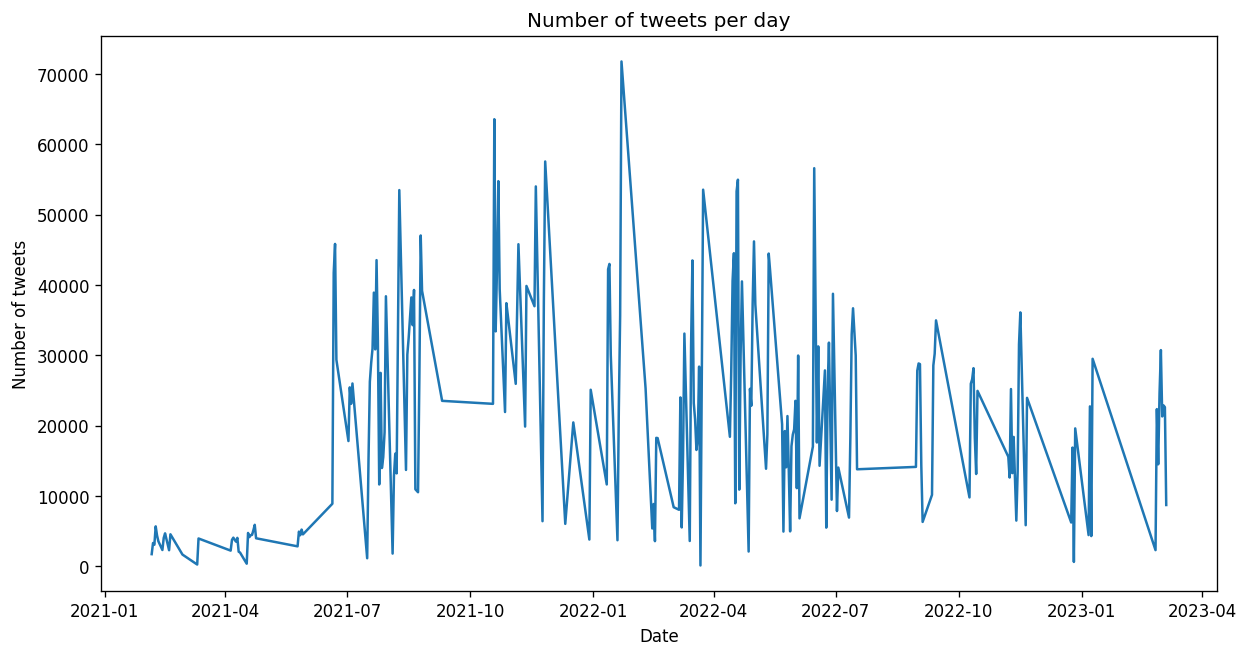

In [18]:
# Plot the line chart
sns.lineplot(data=tweets_per_day, x = 'date', y = 'count')
plt.title('Number of tweets per day')
plt.xlabel('Date')
plt.ylabel('Number of tweets')
plt.show()

<Axes: xlabel='date'>

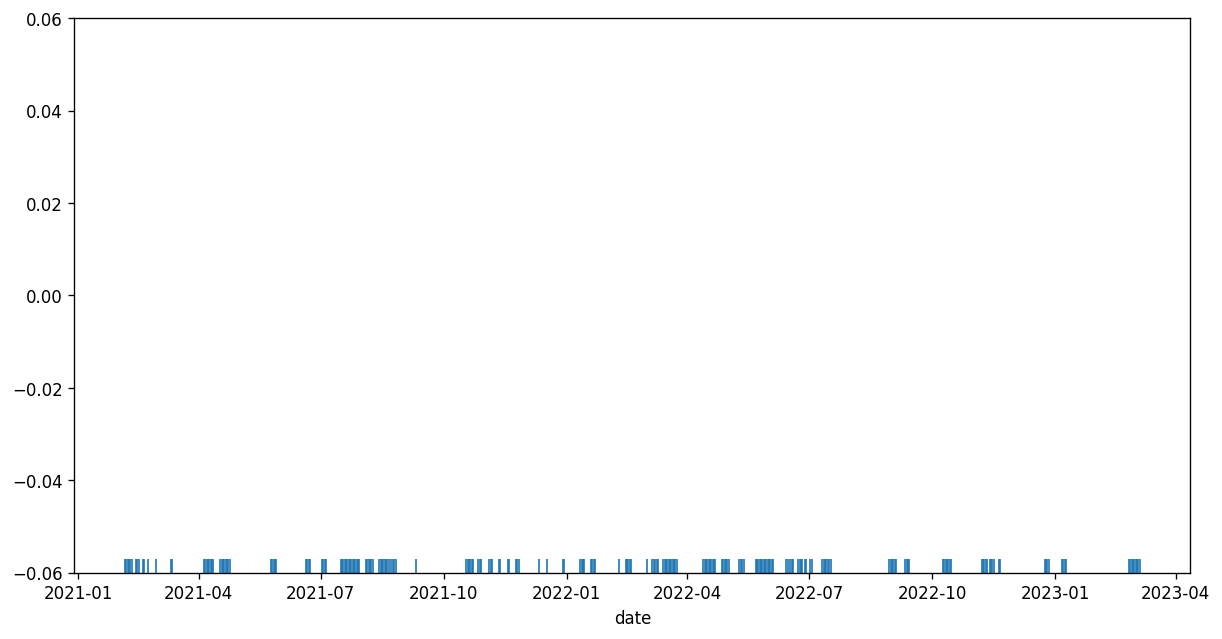

In [19]:
# There appears to be missing dates from the line chart. Checking the rugplot confirms this
sns.rugplot(data=tweets_per_day, x = 'date')

## Text Pre-Processing

In [20]:
# Create a function to convert the tweet to lower case and replce \\, _, . with a space
def lower_case(btc_tweets):
    results = []
    for i in btc_tweets['text']:
        i = str(i).lower().replace('\\',' ').replace('_',' ').replace('.',' ')
        results.append(i)
    btc_tweets['text'] = results
    return btc_tweets

In [21]:
# Create a function to remove email addresses from the tweet
def remove_email(btc_tweets):
    results = []
    for i in btc_tweets['text']:
        i = re.sub(r'\S*@\S*\s?', "", i)
        results.append(i)
    btc_tweets['text'] = results
    return btc_tweets

In [22]:
# Create a function to remove urls from the tweet
def remove_url(btc_tweets):
    results = []
    for i in btc_tweets['text']:
        i = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', "", i)
        results.append(i)
    btc_tweets['text'] = results
    return btc_tweets

In [23]:
# Create a function to remove urls from the tweet
def remove_url(btc_tweets):
    results = []
    for i in btc_tweets['text']:
        i = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', "", i)
        results.append(i)
    btc_tweets['text'] = results
    return btc_tweets

In [24]:
# Create a function to remove special characters from the tweet
def remove_special(btc_tweets):
    results = []
    for i in btc_tweets['text']:
        # Replace anything that is not a letter, number of space with blank
        i = re.sub('[^A-Za-z0-9 ]+', '', i)
        results.append(i)
    btc_tweets['text'] = results
    return btc_tweets

In [25]:
btc_tweets = (btc_tweets
         .pipe(lower_case)
         .pipe(remove_email)
         .pipe(remove_url)
         .pipe(remove_special)
        )

In [26]:
btc_tweets.head()

,user_followers,user_friends,user_favourites,datetime,text,hashtags,date,time
0,8534,7605,4838,2021-02-10 23:59:04,blue ridge bank shares halted by nyse after bitcoin atm announcement coxaazmajkiv cosgbxmkp1si,['bitcoin'],2021-02-10,23:59:04
1,6769,1532,25483,2021-02-10 23:58:48,today thats this thursday we will do a take 2 with our friend btc wallet security expe cogo6adgrml5,"['Thursday', 'Btc', 'wallet', 'security']",2021-02-10,23:58:48
2,128,332,924,2021-02-10 23:54:48,guys evening i have read this article about btc and would like to share with you all coqxczgmuy3b coo6wn7ppkvy,NaN,2021-02-10,23:54:48
3,625,129,14,2021-02-10 23:54:33,btc a big chance in a billion price 4872644 0 20210211 0851 bitcoin fx btc crypto,"['Bitcoin', 'FX', 'BTC', 'crypto']",2021-02-10,23:54:33
4,1249,1472,10482,2021-02-10 23:54:06,this network is secured by 9 508 nodes as of today soon the biggest bears will recognise btc in too big to fail co1xovda8rkw,['BTC'],2021-02-10,23:54:06


## Calculate Sentiment

In [27]:
# Download nltk packages. I will use vader_lexicon for sentiment analysis
#nltk.download('vader_lexicon')
#nltk.download('punkt')

# Instantiate a sentiment intensity analysis
sid = SentimentIntensityAnalyzer()

In [28]:
# Create a function to calculate the sentiment score. The function returns a 1 if the text is positive and returns 0 otherwise
def sentiment_calc(btc_tweets):

    # Create an empty list to store the results
    results = []
 
    # Iterate through all tweets in the dataframe
    for row in btc_tweets['text']:

        # Calculate the sentiment score. The score is returned as a dictionary of positive, negative, neutral and compound results.
        # I want just the compound score
        score = sid.polarity_scores(row)['compound']
        
        # return a 0 or 1 depending on if the sentiment is positive or not positive
        if score > 0.00:
            results.append(1)
        else:
            results.append(0)

    # Save the results as a new column in the btc_tweets dataframe and return the dataframe
    btc_tweets['text_sentiment'] = results
    return btc_tweets

In [29]:
# Run the sentiment_calc function
btc_tweets = btc_tweets.pipe(sentiment_calc)

In [52]:
btc_tweets.head()

,user_followers,user_friends,user_favourites,datetime,text,hashtags,date,time,text_sentiment
0,8534,7605,4838,2021-02-10 23:59:04,blue ridge bank shares halted by nyse after bitcoin atm announcement coxaazmajkiv cosgbxmkp1si,['bitcoin'],2021-02-10,23:59:04,1
1,6769,1532,25483,2021-02-10 23:58:48,today thats this thursday we will do a take 2 with our friend btc wallet security expe cogo6adgrml5,"['Thursday', 'Btc', 'wallet', 'security']",2021-02-10,23:58:48,1
2,128,332,924,2021-02-10 23:54:48,guys evening i have read this article about btc and would like to share with you all coqxczgmuy3b coo6wn7ppkvy,NaN,2021-02-10,23:54:48,1
3,625,129,14,2021-02-10 23:54:33,btc a big chance in a billion price 4872644 0 20210211 0851 bitcoin fx btc crypto,"['Bitcoin', 'FX', 'BTC', 'crypto']",2021-02-10,23:54:33,1
4,1249,1472,10482,2021-02-10 23:54:06,this network is secured by 9 508 nodes as of today soon the biggest bears will recognise btc in too big to fail co1xovda8rkw,['BTC'],2021-02-10,23:54:06,0


In [50]:
# Create dataframes for the number of positive tweets per day and total tweets per day
btc_sent_df = btc_tweets[['date','text_sentiment']]

# Daily sentiment
daily_pos_tweets_count = btc_sent_df.groupby('date').sum()['text_sentiment']
daily_pos_tweets_count = pd.DataFrame(daily_pos_tweets_count).rename(columns={'text_sentiment':'positive_tweets'})

# Total tweets per day
daily_total_tweets_count = btc_sent_df.groupby('date').count()['text_sentiment']
daily_total_tweets_count = pd.DataFrame(daily_total_tweets_count).rename(columns={'text_sentiment':'total_tweets'})

In [58]:
# Join the positive tweets dataframe onto the total tweets dataframe
daily_pos_percent = daily_total_tweets_count.join(daily_pos_tweets_count, how='left', on='date')

# Calculate the percentage positive tweets
daily_pos_percent['Positive_%'] = ((daily_pos_percent['positive_tweets']/daily_pos_percent['total_tweets'])*100).apply(lambda x: math.floor(x))

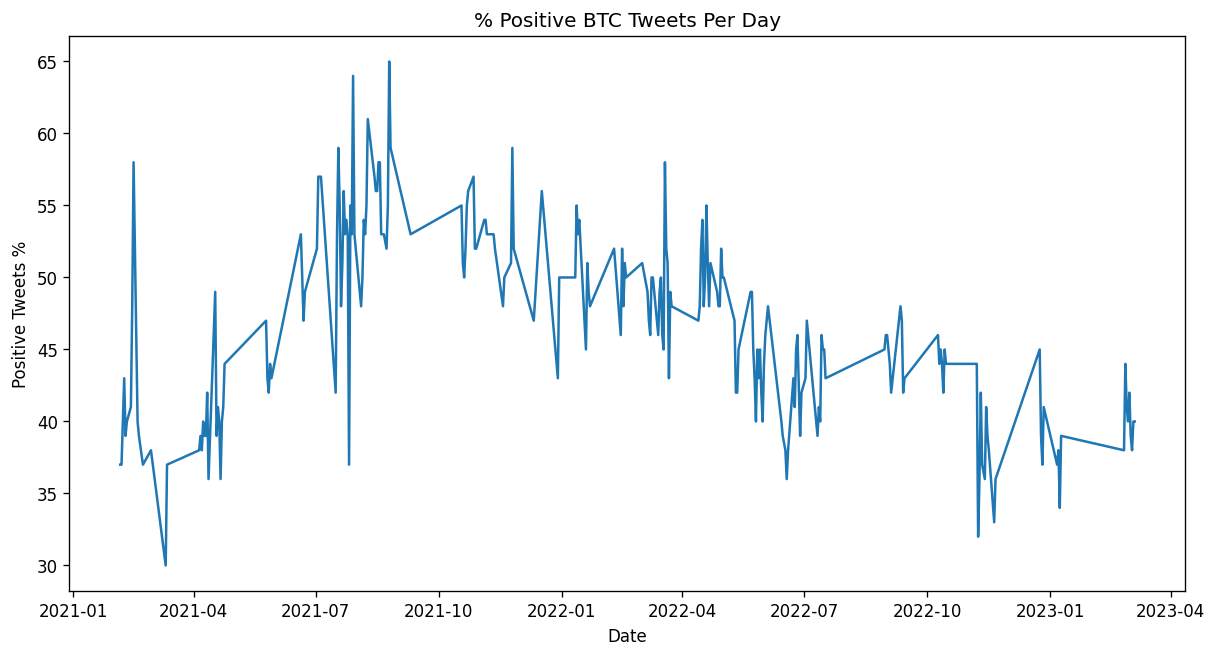

In [61]:
# Plot the percentage of positive tweets per day
sns.lineplot(daily_pos_percent, x = 'date', y = 'Positive_%')
plt.title('% Positive BTC Tweets Per Day')
plt.xlabel('Date')
plt.ylabel('Positive Tweets %')
plt.show()